# Projeto PCS5022

inspirado por https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen2.5_VL_(7B)-Vision.ipynb

### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

### Configuração

In [2]:
TREINAR_MODELO = True # True para treinar o modelo, False para não treinar e usar o módulo de inferencia (previsão)
CONTINUAR_TREINAMENTO = True # True para continuar o treinamento de um modelo já treinado, False para treinar do zero
GERAR_INFERENCIAS = not TREINAR_MODELO # aqui deixa claro que o códgio gera inferências de não for treinar
INFERIR_DEPOIS_DE_TREINAR = True # se TREINAR_MODELO for True, então o código vai gerar inferências depois de treinar o modelo
EPOCAS = 1 # define a quantidade de épocas para treinar
LORA_SAVED = "qwen_lora" # pasta com o LoRA salvo para ser restaurado se necessário
MODELO_4BIT = "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit" # eu não consegui rodar o Qwen2-VL-2B por erro de Out Of Memory (OOM) e encontrei um artigo falado que o modelo 4bit consegue rodar bem sem estourar a memória do Google Colab
REDUZIR_IMAGENS = True # vou deixar essa configuração disponível se quisermos manter o tamanho original das imagens no treino ou inferencia
MAX_SHAPE = (600, 600) # define o tamanho máximo de cada dimensão da imagem. Obs: o resize será feito mantendo a proporcionalidade da imagem
TAMANHO_SPLIT_TREINO = 0.9 # ou seja, a validação será (1 - TAMANHO_SPLIT_TREINO) no caso inicial validaçção será 10% (200 amostras)

#KAGGLE_API_TOKEN esta chave não deve ficar exposta aqui, deve ser colocada no meu Secrets, para fazer o download das imagens e jsonl

### Unsloth

In [3]:
# restaurar o arquivo zipado do Google Drive se for definido GERAR_INFERENCIAS
import shutil
from pathlib import Path
from unsloth import FastVisionModel

if INFERIR_DEPOIS_DE_TREINAR:
  GERAR_INFERENCIAS = True  # Forçar a geração de inferências após o treinamento

def esta_no_colab():
  try:
    import google.colab  # type: ignore
    return True
  except ImportError:
    return False


def localizar_zip_lora(filename):
  """Procura o ZIP do LoRA em locais compatíveis com Colab e ambiente local."""
  base_name = Path(filename).stem
  timestamp_pattern = f"{base_name}_*.zip"
  locais = [Path.cwd(), Path.cwd() / "backups"]

  if esta_no_colab():
    locais.append(Path('/content/drive/MyDrive/Colab Notebooks'))

  candidatos = []
  for local in locais:
    candidatos.append(local / filename)
    candidatos.extend(sorted(local.glob(timestamp_pattern), key=lambda path: path.stat().st_mtime, reverse=True))

  for candidato in candidatos:
    if candidato.exists():
      return candidato

  return None


def carregar_modelo_salvo(lora_saved=LORA_SAVED):
  """
  Carrega o qwen_lora salvo do disco local ou do Google Drive quando estiver no Colab.
  """
  pasta_lora = Path(lora_saved)
  filename = f"{lora_saved}.zip"

  # 1. Verificar se a pasta do modelo já existe localmente
  if not pasta_lora.exists():
    print(f"Pasta '{lora_saved}' não encontrada localmente. Procurando o arquivo '{filename}'...")

    if esta_no_colab():
      from google.colab import drive
      drive.mount('/content/drive')

    zip_path = localizar_zip_lora(filename)

    # 2. Verificar se o ZIP existe em algum local conhecido
    if zip_path is None:
      locais = [str(Path.cwd()), str(Path.cwd() / 'backups')]
      if esta_no_colab():
        locais.append('/content/drive/MyDrive/Colab Notebooks')
      print(f"O arquivo {filename} não foi encontrado. Locais verificados: {locais}")
      return None, None

    try:
      print(f"Descompactando {zip_path}...")
      shutil.unpack_archive(str(zip_path), extract_dir=str(Path.cwd()))
      print("Modelo restaurado com sucesso.")
    except Exception as e:
      print(f"Erro ao processar o arquivo zip: {e}")
      return None, None

  # 3. Carregar o modelo usando Unsloth
  try:
    print(f"Carregando modelo da pasta '{lora_saved}'...")
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = lora_saved,
        load_in_4bit = True,
    )
    return model, tokenizer
  except Exception as e:
    print(f"Erro ao carregar o modelo salvo: {e}")
    return None, None


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

def carrega_modelo():
  model, tokenizer = FastVisionModel.from_pretrained(
      MODELO_4BIT,
      load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
      use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
  )
  return model, tokenizer

if TREINAR_MODELO:
  if not CONTINUAR_TREINAMENTO:
    model, tokenizer = carrega_modelo()
  else:
    model, tokenizer = carregar_modelo_salvo()
    if model is None or tokenizer is None:
      print("Não foi possível carregar o modelo salvo. Treinando do zero.")
      model, tokenizer = carrega_modelo()

Carregando modelo da pasta 'qwen_lora'...
==((====))==  Unsloth 2026.7.2: Fast Qwen2_5_Vl patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.928 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [5]:
if TREINAR_MODELO:
  if not CONTINUAR_TREINAMENTO:
    model = FastVisionModel.get_peft_model(
        model,
        finetune_vision_layers     = True, # False if not finetuning vision layers
        finetune_language_layers   = True, # False if not finetuning language layers
        finetune_attention_modules = True, # False if not finetuning attention layers
        finetune_mlp_modules       = True, # False if not finetuning MLP layers

        r = 16,           # The larger, the higher the accuracy, but might overfit
        lora_alpha = 16,  # Recommended alpha == r at least
        lora_dropout = 0,
        bias = "none",
        random_state = 3407,
        use_rslora = False,  # We support rank stabilized LoRA
        loftq_config = None, # And LoftQ
        # target_modules = "all-linear", # Optional now! Can specify a list if needed
    )

<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [6]:
# @title
import kagglehub
import json
from datasets import Dataset
from PIL import Image # Import Pillow for image loading
import os # Ensure os is imported for path operations
from tqdm import tqdm

if "KAGGLE_" in "".join(os.environ.keys()):
    print("Kaggle API token found in environment variables.")
else:
    from dotenv import load_dotenv
    print("Kaggle API token not found in environment variables. Loading from .env file.")
    load_dotenv()  # Load environment variables from .env file



path = kagglehub.competition_download('pcs-3838-pcs-5022-2026-parte-2')

print("Path to competition files:", path)

###
### Parte 1. Carregar os dados do JSON e imagens no formato do Qwen2-VL
###

# função para carregar os dados do JSON e imagens no formato do Qwen2-VL
def carregar_dados_qwen(jsonl_path, pasta_imagens):

    lista_formatada = []

    max_shape = MAX_SHAPE

    # 1. Abrir o arquivo JSONL e ler linha por linha

    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for linha in tqdm(f, desc="Carregando dataset..."):

            # Ignora linhas vazias que possam existir no final do arquivo
            if not linha.strip():
                continue

            # Transforma a linha atual em um dicionário Python
            item = json.loads(linha)

            # 2. Extrair os dados (ajuste os nomes das chaves se forem diferentes)
            idx = item['index']
            pergunta = item['question']
            resposta = item.get('answer', '')

            pergunta_formatada = f"<image>\n{pergunta}"

            # Construir o caminho da imagem baseado no padrão 'circuit_n.png'
            caminho_imagem = os.path.join(pasta_imagens, f"circuit_{idx}.png")

            # verificar se a imagem existe
            if not os.path.exists(caminho_imagem):
                print(f"Imagem não encontrada: {caminho_imagem}")
                continue

            # Carregar a imagem usando Pillow
            image_pil = Image.open(caminho_imagem)

            # Obter as dimensões originais da imagem
            largura_original, altura_original = image_pil.size

            # Inicializa image_resized com a imagem original
            image_resized = image_pil

            # Avaliar as dimensões da imagem e redimensionar se necessário
            if (largura_original > max_shape[0] or altura_original > max_shape[1]) and REDUZIR_IMAGENS:
                max_original = max(largura_original, altura_original)
                divs = max_original // max_shape[0]
                if divs > 1:
                    nova_largura = largura_original // divs
                    nova_altura = altura_original // divs
                    image_resized = image_pil.resize((nova_largura, nova_altura), Image.Resampling.LANCZOS)
                # Else: image_resized já é image_pil (o que significa que divs <= 1 e não precisa redimensionar)

            # Exibir a imagem redimensionada (este comando só funciona em notebooks para exibição direta)
            # Remover esta linha ou comentar se não for para exibição interativa
            # image_resized

            # Estrutura de mensagens do Qwen2-VL
            mensagens = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image_resized}, # Use o objeto da imagem PIL aqui
                        {"type": "text", "text": pergunta_formatada}
                    ]
                }
            ]

            # Se for dado de treino, adicionamos a resposta do assistente
            if resposta:
                mensagens.append({
                    "role": "assistant",
                    "content": [
                        {"type": "text", "text": resposta}
                    ]
                })

            lista_formatada.append({
                "messages": mensagens,
                "id": idx
            })

    # 3. Retornar a lista formatada (não como um Dataset do Hugging Face para manter objetos PIL)
    return lista_formatada

if TREINAR_MODELO:
    # Iniciando o carregamento dos dados do treino
    print("Carregando dados do treino...\n")
    train_path = os.path.join(path, 'kaggle_dataset/train_dataset')  # Ajuste conforme necessário

    train_json_path = os.path.join(train_path, 'text/questions_with_answers.jsonl')  # Ajuste conforme necessário
    train_image_path = os.path.join(train_path, 'images/')  # Ajuste conforme necessário
    dataset_treino = carregar_dados_qwen(train_json_path, train_image_path)

    # analisa uma entrada do dataset
    print(dataset_treino[0])  # Mostra a primeira entrada do dataset

    print(f"Total de exemplos no dataset de treino: {len(dataset_treino)}\n")

Kaggle API token found in environment variables.
Path to competition files: /home/bruno/.cache/kagglehub/competitions/pcs-3838-pcs-5022-2026-parte-2
Carregando dados do treino...



Carregando dataset...: 2000it [00:51, 39.16it/s]

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGBA size=654x193 at 0x7E4A89C852E0>}, {'type': 'text', 'text': '<image>\nHow many and gates are in this logic circuit?'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': '2'}]}], 'id': 0}
Total de exemplos no dataset de treino: 2000



In [7]:
print(dataset_treino[0] if TREINAR_MODELO else "Dataset de treino não carregado porque TREINAR_MODELO está definido como False.")

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGBA size=654x193 at 0x7E4A89C852E0>}, {'type': 'text', 'text': '<image>\nHow many and gates are in this logic circuit?'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': '2'}]}], 'id': 0}


To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

# **Análise das imagens**

Percebi que as imagens tem grandes dimenões exemplo (1900, 700) e apliquei uma redução (resize) na função de carregamento de dados

Na primeira rodada de treinamentos sem a reduçção de imagem, o modelo demorava cerca de 20 segudos por imagem para ser treinado, após a redução, o modelo levou cerca de 2 segundos por imagem. Um ganho de 10 vezes.

In [8]:
# pegar a imagem em dataset_treino[0]["messages"] usando biblioteca json
# The 'json' library is not needed here as the data is already a Python object.
# The image is part of the user's message, which is the first item in the 'messages' list.
# Within the user's message, the 'content' is a list, and the image is the first item in that content list.
if TREINAR_MODELO:
    image_test = dataset_treino[0]["messages"][0]["content"][0]["image"]

    # plot imagem_test
    image_test


In [9]:
print(image_test.size if TREINAR_MODELO else "Imagem de teste não carregada porque TREINAR_MODELO está definido como False.")

(654, 193)


Let's first see before we do any finetuning what the model outputs for the first example!

In [10]:
# este bloco apresenta uma demonstração de inferencia do modelo sem treinamento
# e não interfere no treinamento ou na inferencia
# alterar para True para verificar a resposta do modelo antes do treinamento
if False:
  try:
    FastVisionModel.for_inference(model) # Enable for inference!
  except:
    model, tokenizer = carrega_modelo()
    FastVisionModel.for_inference(model) # Enable for inference!

  image = image_test
  instruction = "Descreva as portas lógicas desta imagem"

  messages = [
      {"role": "user", "content": [
          {"type": "image"},
          {"type": "text", "text": instruction}
      ]}
  ]
  input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
  inputs = tokenizer(
      image,
      input_text,
      add_special_tokens = False,
      return_tensors = "pt",
  ).to("cuda")

  from transformers import TextStreamer
  text_streamer = TextStreamer(tokenizer, skip_prompt = True)
  _ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                    use_cache = True, temperature = 1.5, min_p = 0.1)

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [11]:
if TREINAR_MODELO:
  from unsloth.trainer import UnslothVisionDataCollator
  from trl import SFTTrainer, SFTConfig

  FastVisionModel.for_training(model) # Enable for training!

  trainer = SFTTrainer(
      model = model,
      tokenizer = tokenizer,
      data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
      train_dataset = dataset_treino,
      args = SFTConfig(
          per_device_train_batch_size = 2,
          gradient_accumulation_steps = 4,
          warmup_steps = 5,
          #max_steps = 30,
          num_train_epochs = EPOCAS, # Set this instead of max_steps for full training runs
          learning_rate = 2e-4,
          logging_steps = 1,
          optim = "adamw_8bit",
          weight_decay = 0.001,
          lr_scheduler_type = "linear",
          seed = 3407,
          output_dir = "outputs",
          report_to = "none",     # For Weights and Biases

          # You MUST put the below items for vision finetuning:
          remove_unused_columns = False,
          dataset_text_field = "",
          dataset_kwargs = {"skip_prepare_dataset": True},
          max_length = 2048,
      ),
  )

Unsloth: Model does not have a default image size - using 512


In [12]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA GeForce RTX 5060 Ti. Max memory = 15.928 GB.
7.057 GB of memory reserved.


### Split train and validation data

In [13]:
# Definir o tamanho do split
if TREINAR_MODELO:
  print(f"Porcentagem do Split Treino/Validação: {TAMANHO_SPLIT_TREINO:.1%}/{(1-TAMANHO_SPLIT_TREINO):.1%}")
  split_index = int(len(dataset_treino) * TAMANHO_SPLIT_TREINO)

  # Criar o dataset de validação
  dataset_validation = dataset_treino[split_index:]

  # Atualizar o dataset de treino para conter apenas os 90% iniciais
  dataset_treino = dataset_treino[:split_index]

  print(f"Tamanho do dataset de treino: {len(dataset_treino)}")
  print(f"Tamanho do dataset de validação: {len(dataset_validation)}")

Porcentagem do Split Treino/Validação: 90.0%/10.0%
Tamanho do dataset de treino: 1800
Tamanho do dataset de validação: 200


In [14]:
if TREINAR_MODELO:
    trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,521,536 of 8,343,688,192 (0.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,0.015200
2,0.013600
3,0.015800
4,0.012800
5,0.014200
6,0.015200
7,0.015700
8,0.026500
9,0.016500
10,0.026100


### Avalição do treinamento com dataset_validation

Iniciando inferência em 200 exemplos de validação...


100%|██████████| 200/200 [01:32<00:00,  2.17it/s]


--- Tabela de Resultados (Amostra) ---


,id,pergunta,esperado,predicao,correto
0,1800,"What is the output of this logic circuit, give...",False,False,True
1,1801,How many and gates are in this logic circuit?,3,3,True
2,1802,"What is the output of this logic circuit, give...",False,False,True
3,1803,How many not gates are in this logic circuit?,3,3,True
4,1804,How many and gates are in this logic circuit?,1,1,True
5,1805,"What is the output of this logic circuit, give...",False,True,False
6,1806,How many or gates are in this logic circuit?,2,2,True
7,1807,How many xor gates are in this logic circuit?,1,1,True
8,1808,How many xnor gates are in this logic circuit?,0,0,True
9,1809,"What is the output of this logic circuit, give...",True,True,True



Acurácia no Dataset de Validação: 87.00%


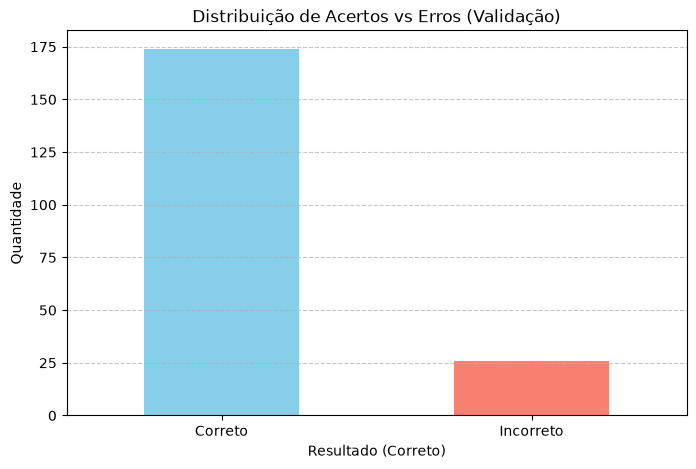

In [16]:
# célula de avaliação do modelo treinado, que gera inferências e avalia a acurácia
if TREINAR_MODELO:
  import pandas as pd
  import matplotlib.pyplot as plt
  from tqdm import tqdm

  # Garantir que o modelo está em modo de inferência
  FastVisionModel.for_inference(model)

  resultados = []

  print(f"Iniciando inferência em {len(dataset_validation)} exemplos de validação...")

  for item in tqdm(dataset_validation):
      idx = item['id']
      messages = item['messages']

      # A estrutura do dataset tem a imagem e o texto no primeiro item (user)
      image = messages[0]['content'][0]['image']
      instruction = messages[0]['content'][1]['text']
      ground_truth = messages[1]['content'][0]['text'] # Resposta do assistant

      # Preparar inputs
      input_text = tokenizer.apply_chat_template([messages[0]], add_generation_prompt = True)
      inputs = tokenizer(
          image,
          input_text,
          add_special_tokens = False,
          return_tensors = "pt",
      ).to("cuda")

      # Gerar resposta
      output = model.generate(
          **inputs,
          max_new_tokens = 64,
          use_cache = True,
          temperature = 1.0,
          min_p = 0.1
      )

      # Decodificar a resposta (removendo o prompt)
      prediction = tokenizer.decode(output[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()

      resultados.append({
          "id": idx,
          "pergunta": instruction.replace("<image>\n", ""),
          "esperado": ground_truth,
          "predicao": prediction,
          "correto": ground_truth.lower() == prediction.lower()
      })

  # Criar DataFrame para análise
  df_resultados = pd.DataFrame(resultados)

  # 1. Exibir Tabela de Resultados (primeiras 10 linhas)
  print("\n--- Tabela de Resultados (Amostra) ---")
  display(df_resultados.head(10))

  # 2. Análise de Acurácia
  accuracy = df_resultados['correto'].mean() * 100
  print(f"\nAcurácia no Dataset de Validação: {accuracy:.2f}%")

  # 3. Gráfico de Resultados
  plt.figure(figsize=(8, 5))
  df_resultados['correto'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
  plt.title('Distribuição de Acertos vs Erros (Validação)')
  plt.xlabel('Resultado (Correto)')
  plt.ylabel('Quantidade')
  plt.xticks([0, 1], ['Correto', 'Incorreto'] if df_resultados['correto'].iloc[0] else ['Incorreto', 'Correto'], rotation=0)
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

In [17]:
# salvar resultados do treinamento e inferência em um arquivo CSV
if TREINAR_MODELO:
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    resultados_csv_path = f"resultados/resultados_inferencia_{timestamp}.csv"
    df_resultados.to_csv(resultados_csv_path, index=False)
    print(f"Resultados da inferência salvos em: {resultados_csv_path}")

Resultados da inferência salvos em: resultados/resultados_inferencia_2026-07-12_16-31-48.csv


In [18]:
# @title Show final memory and time stats
if TREINAR_MODELO:
    used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
    used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
    used_percentage = round(used_memory / max_memory * 100, 3)
    lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
    print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
    print(
        f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
    )
    print(f"Peak reserved memory = {used_memory} GB.")
    print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
    print(f"Peak reserved memory % of max memory = {used_percentage} %.")
    print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

797.0383 seconds used for training.
13.28 minutes used for training.
Peak reserved memory = 7.998 GB.
Peak reserved memory for training = 0.941 GB.
Peak reserved memory % of max memory = 50.213 %.
Peak reserved memory for training % of max memory = 5.908 %.


### Gráfico de Loss

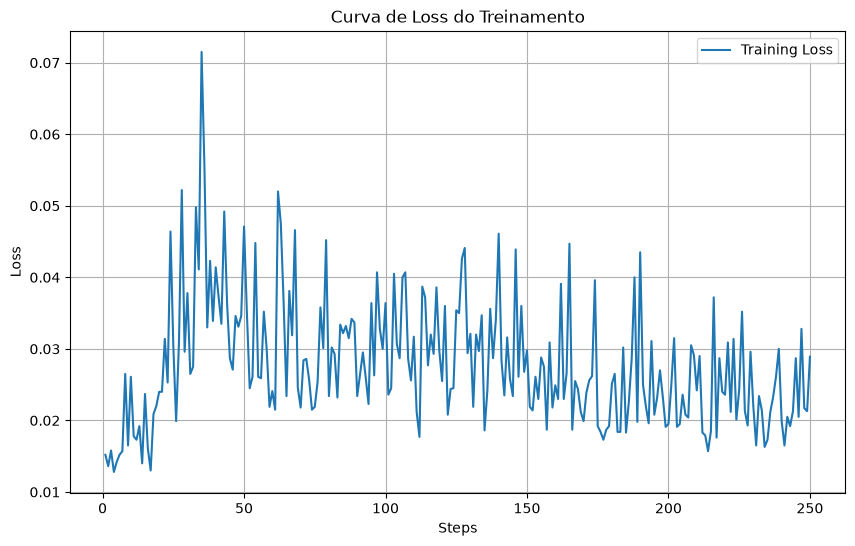

In [19]:
if TREINAR_MODELO:
    import matplotlib.pyplot as plt
    # Extrair os logs de perda
    history = trainer.state.log_history
    losses = [x['loss'] for x in history if 'loss' in x]
    steps = [x['step'] for x in history if 'loss' in x]

    # Criar o gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, label="Training Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Curva de Loss do Treinamento")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("O modelo não foi treinado nesta sessão (TREINAR_MODELO = False). No entanto, se você carregou o modelo, os logs estariam disponíveis no objeto trainer.")

### Salvar o modelo treinado

In [20]:
# Salvar o modelo e o tokenizer localmente
# (Se você encontrou um 'NameError' anteriormente, execute as células QmUBVEnvCDJv, 6bZsfBuZDeCL e yqxqAZ7KJ4oL novamente antes desta)
if TREINAR_MODELO:
    model.save_pretrained("qwen_lora")
    tokenizer.save_pretrained("qwen_lora")
    print("Modelo e tokenizer salvos em 'qwen_lora/'.")

Modelo e tokenizer salvos em 'qwen_lora/'.


Agora, vamos compactar a pasta `qwen_lora` em um arquivo `.zip`.

In [21]:
if TREINAR_MODELO:
    import shutil
    from pathlib import Path

    lora_dir = Path("qwen_lora")
    output_zip_name = f"qwen_lora_{timestamp}.zip"
    output_zip_base = output_zip_name.removesuffix(".zip")

    if not lora_dir.exists():
        print(f"Erro: pasta '{lora_dir}' não encontrada.")
    else:
        zip_path = shutil.make_archive(
            base_name=output_zip_base,
            format="zip",
            root_dir=Path.cwd(),
            base_dir=lora_dir.name,
        )
        print(f"Pasta '{lora_dir}' compactada para '{output_zip_name}'.")

        if Path(zip_path).exists():
            print(f"O arquivo '{output_zip_name}' está pronto para download.")
        else:
            print(f"Erro: O arquivo '{output_zip_name}' não foi criado.")

Pasta 'qwen_lora' compactada para 'qwen_lora_2026-07-12_16-31-48.zip'.
O arquivo 'qwen_lora_2026-07-12_16-31-48.zip' está pronto para download.


In [22]:
if TREINAR_MODELO:
    import shutil
    from pathlib import Path

    lora_dir = Path("qwen_lora")
    output_zip_name = f"qwen_lora_{timestamp}.zip"
    output_zip_base = output_zip_name.removesuffix(".zip")

    if not lora_dir.exists():
        print(f"Erro: pasta '{lora_dir}' não encontrada.")
    else:
        zip_path = shutil.make_archive(
            base_name=output_zip_base,
            format="zip",
            root_dir=Path.cwd(),
            base_dir=lora_dir.name,
        )
        print(f"Pasta '{lora_dir}' compactada para '{output_zip_name}'.")

        if Path(zip_path).exists():
            print(f"O arquivo '{output_zip_name}' está pronto para download.")
        else:
            print(f"Erro: O arquivo '{output_zip_name}' não foi criado.")

Pasta 'qwen_lora' compactada para 'qwen_lora_2026-07-12_16-31-48.zip'.
O arquivo 'qwen_lora_2026-07-12_16-31-48.zip' está pronto para download.


### Save timestamped LoRA ZIP to Google Drive

In [23]:
if TREINAR_MODELO:
    # @title
    import os
    import shutil
    from pathlib import Path

    def esta_no_colab():
        try:
            import google.colab  # type: ignore
            return True
        except ImportError:
            return False

    output_zip_name = f"qwen_lora_{timestamp}.zip"
    source_path = Path.cwd() / output_zip_name

    if not source_path.exists():
        print(f"Erro: '{output_zip_name}' não encontrado em '{source_path}'. Gere o zip antes de copiar.")
    elif esta_no_colab():
        from google.colab import drive

        drive.mount('/content/drive')
        drive_folder = Path('/content/drive/MyDrive/Colab Notebooks')
        drive_folder.mkdir(parents=True, exist_ok=True)
        destination_path = drive_folder / output_zip_name

        shutil.copy2(source_path, destination_path)
        print(f"'{output_zip_name}' copiado para o Google Drive em '{destination_path}'.")
    else:
        local_backup_folder = Path.cwd() / "backups"
        local_backup_folder.mkdir(parents=True, exist_ok=True)
        destination_path = local_backup_folder / output_zip_name

        shutil.copy2(source_path, destination_path)
        print(f"Ambiente local detectado. '{output_zip_name}' copiado para '{destination_path}'.")


Ambiente local detectado. 'qwen_lora_2026-07-12_16-31-48.zip' copiado para '/home/bruno/PCS5022-Kaggle/backups/qwen_lora_2026-07-12_16-31-48.zip'.


<a name="Inference"></a>
# Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [24]:
# carregar o modelo
if GERAR_INFERENCIAS:
  try:
    FastVisionModel.for_inference(model) # Enable for inference!
  except NameError:
    model, tokenizer = carregar_modelo_salvo()
    if model is not None:
      FastVisionModel.for_inference(model) # Enable for inference!
  except Exception as e:
    print(f"Modelo atual não estava pronto para inferência: {e}")
    model, tokenizer = carregar_modelo_salvo()
    if model is not None:
      FastVisionModel.for_inference(model) # Enable for inference!


Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [25]:
# demonstração de inferência do modelo recuperado
if False:  # Alterar para True para testar a inferência
    
    image = image_test
    instruction = "Describe the gates in image"

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]}
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")

    from transformers import TextStreamer
    text_streamer = TextStreamer(tokenizer, skip_prompt = True)
    _ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1028,
                    use_cache = True, temperature = 1.5, min_p = 0.1)

### Carregar dataset de teste

In [26]:
if GERAR_INFERENCIAS:
    import os
    JSONL_PATH = os.path.join(path, 'kaggle_dataset/test_dataset/text/questions.jsonl')  # Ajuste conforme necessário
    IMAGE_PATH = os.path.join(path, 'kaggle_dataset/test_dataset/images/')  # Ajuste conforme necessário
    dataset_test = carregar_dados_qwen(JSONL_PATH, IMAGE_PATH)

Carregando dataset...: 1000it [00:28, 34.74it/s]


In [27]:
# ver dataset_test[0]
print(dataset_test[0] if GERAR_INFERENCIAS else "Dataset de teste não carregado porque GERAR_INFERENCIAS está definido como False.")


{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGBA size=752x268 at 0x7E4A7AF7F7A0>}, {'type': 'text', 'text': '<image>\nHow many xnor gates are in this logic circuit?'}]}], 'id': 0}


In [28]:
# ver imagem de dataset_test[0]["messages"][0]["content"][0]["image"]
print(dataset_test[0]["messages"][0]["content"][0]["image"] if GERAR_INFERENCIAS else "Imagem de teste não carregada porque GERAR_INFERENCIAS está definido como False.")

<PIL.Image.Image image mode=RGBA size=752x268 at 0x7E4A7AF7F7A0>


In [29]:
# tamanho da imagem de dataset_test[0]["messages"][0]["content"][0]["image"]
print(dataset_test[0]["messages"][0]["content"][0]["image"].size if GERAR_INFERENCIAS else "Imagem de teste não carregada porque GERAR_INFERENCIAS está definido como False.")

(752, 268)


### Realizar as inferências

In [30]:
if GERAR_INFERENCIAS:
    resultados = []

    print(f"Iniciando inferência em {len(dataset_test)} exemplos de validação...")

    for item in tqdm(dataset_test, desc="Inferindo exemplos de teste", unit="imagem-texto"):
        idx = item['id']
        messages = item['messages']

        # A estrutura do dataset tem a imagem e o texto no primeiro item (user)
        image = messages[0]['content'][0]['image']
        instruction = messages[0]['content'][1]['text']
        
        # Preparar inputs
        input_text = tokenizer.apply_chat_template([messages[0]], add_generation_prompt = True)
        inputs = tokenizer(
            image,
            input_text,
            add_special_tokens = False,
            return_tensors = "pt",
        ).to("cuda")

        # Gerar resposta
        output = model.generate(
            **inputs,
            max_new_tokens = 64,
            use_cache = True,
            temperature = 1.0,
            min_p = 0.1
        )

        # Decodificar a resposta (removendo o prompt)
        prediction = tokenizer.decode(output[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()

        resultados.append({
            "index": idx,
            "answer": prediction,
        })
    print(f"Inferência concluída para {len(resultados)} exemplos de teste.")

Iniciando inferência em 1000 exemplos de validação...


Inferindo exemplos de teste: 100%|██████████| 1000/1000 [07:23<00:00,  2.25imagem-texto/s]

Inferência concluída para 1000 exemplos de teste.


### Salvar inferencias em submission.csv

In [31]:
# salvar resultados em CSV
if GERAR_INFERENCIAS:
    import pandas as pd
    from datetime import datetime
    df_resultados_test = pd.DataFrame(resultados)
    submission_fname = f"submissions/submission-{datetime.now().strftime('%Y-%m-%d-%H-%M-%S')}.csv"
    df_resultados_test.to_csv(submission_fname, index=False)
    print(f"Resultados de inferência salvos em '{submission_fname}'.")

Resultados de inferência salvos em 'submissions/submission-2026-07-12-16-39-55.csv'.


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [32]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit (~4GB to download)
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)
</div>